In [ ]:
#loading in tensor flow and importing data/other needed
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow.keras as keras
from d2l import tensorflow as d2l



from tensorflow.keras.utils import image_dataset_from_directory

train_df = image_dataset_from_directory(directory="/localhome/sv6393/MLData/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train",
                                         image_size=(256, 256))
valid_df = image_dataset_from_directory(directory="/localhome/sv6393/MLData/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid",
                                        image_size=(256, 256))


Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


In [ ]:

class_names = train_df.class_names
num_classes = len(class_names)

print("Disease Classes in the Dataset:")
for idx, class_name in enumerate(class_names):
    print(f"{idx}: {class_name}")

def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    label = tf.one_hot(label, depth=num_classes)
    return image, label

train_df = train_df.map(preprocess)
valid_df = valid_df.map(preprocess)

x_train = train_df
x_valid = valid_df

Disease Classes in the Dataset:
0: Apple___Apple_scab
1: Apple___Black_rot
2: Apple___Cedar_apple_rust
3: Apple___healthy
4: Blueberry___healthy
5: Cherry_(including_sour)___Powdery_mildew
6: Cherry_(including_sour)___healthy
7: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8: Corn_(maize)___Common_rust_
9: Corn_(maize)___Northern_Leaf_Blight
10: Corn_(maize)___healthy
11: Grape___Black_rot
12: Grape___Esca_(Black_Measles)
13: Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14: Grape___healthy
15: Orange___Haunglongbing_(Citrus_greening)
16: Peach___Bacterial_spot
17: Peach___healthy
18: Pepper,_bell___Bacterial_spot
19: Pepper,_bell___healthy
20: Potato___Early_blight
21: Potato___Late_blight
22: Potato___healthy
23: Raspberry___healthy
24: Soybean___healthy
25: Squash___Powdery_mildew
26: Strawberry___Leaf_scorch
27: Strawberry___healthy
28: Tomato___Bacterial_spot
29: Tomato___Early_blight
30: Tomato___Late_blight
31: Tomato___Leaf_Mold
32: Tomato___Septoria_leaf_spot
33: Tomato___S

'\nfrom tensorflow.keras.layers.experimental.preprocessing import Rescaling\nrescale = Rescaling(scale=1.0/255)\ntrain_df = train_df.map(lambda image,label:(rescale(image),label))\ntest_df  = test_df.map(lambda image,label:(rescale(image),label))\n'

In [ ]:
#Model Creation:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense,Conv2D,MaxPool2D,Flatten,Dropout,BatchNormalization,)

model = Sequential()

model.add(Conv2D(64, (3, 3), strides=1, padding="same", activation="relu", input_shape=(256, 256, 3)))
model.add(Conv2D(64, (3, 3), strides=1, padding="same", activation="relu"))
model.add(MaxPool2D((2, 2), strides=2, padding="same"))
model.add(Dropout(0.2))#

model.add(BatchNormalization())#
model.add(Conv2D(128, (3, 3), strides=1, padding="same", activation="relu"))
model.add(Conv2D(128, (3, 3), strides=1, padding="same", activation="relu"))
model.add(MaxPool2D((2, 2), strides=2, padding="same"))
model.add(Dropout(0.2))#

model.add(BatchNormalization())#
model.add(Conv2D(256, (3, 3), strides=1, padding="same", activation="relu"))
model.add(Conv2D(256, (3, 3), strides=1, padding="same", activation="relu"))
model.add(MaxPool2D((2, 2), strides=2, padding="same"))
model.add(Dropout(0.2))#

model.add(BatchNormalization())#
model.add(Conv2D(512, (3, 3), strides=1, padding="same", activation="relu"))
model.add(Conv2D(512, (3, 3), strides=1, padding="same", activation="relu"))
model.add(Dropout(0.2))#

model.add(Flatten())
model.add(BatchNormalization())#
model.add(Dense(units=128, activation="relu"))
model.add(Dropout(0.2))
model.add(BatchNormalization())#
model.add(Dense(units=num_classes, activation="softmax"))

In [39]:
#Model Summarization and Compiling
model.summary()
model.compile(loss="categorical_crossentropy", metrics=["accuracy"])



Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_48 (Conv2D)              │ (None, 256, 256, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 256, 256, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 128, 128, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 128, 128, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_51 (Conv2D)              │ (None, 128, 128, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 64, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_52 (Conv2D)              │ (None, 64, 64, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 64, 64, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 32, 32, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 32, 32, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 32, 32, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 32, 32, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 524288)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_33          │ (None, 524288)         │     2,097,152 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    67,108,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_34          │ (None, 128)            │           51

 Total params: 73,898,726 (281.90 MB)

 Trainable params: 72,848,998 (277.90 MB)

 Non-trainable params: 1,049,728 (4.00 MB)

In [ ]:
#Model Training

Model = model.fit(train_df, validation_data=valid_df, epochs=6)


Epoch 1/6
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 461s 208ms/step - accuracy: 0.5375 - loss: 1.6340 - val_accuracy: 0.6649 - val_loss: 1.1725
Epoch 2/6
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 453s 206ms/step - accuracy: 0.8669 - loss: 0.4286 - val_accuracy: 0.7122 - val_loss: 1.1522
Epoch 3/6
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 452s 206ms/step - accuracy: 0.9126 - loss: 0.2742 - val_accuracy: 0.8512 - val_loss: 0.4713
Epoch 4/6
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 452s 206ms/step - accuracy: 0.9362 - loss: 0.1970 - val_accuracy: 0.5990 - val_loss: 2.2204
Epoch 5/6
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 452s 206ms/step - accuracy: 0.9477 - loss: 0.1581 - val_accuracy: 0.7186 - val_loss: 1.3478
Epoch 6/6
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 452s 206ms/step - accuracy: 0.9576 - loss: 0.1318 - val_accuracy: 0.6466 - val_loss: 1.7855


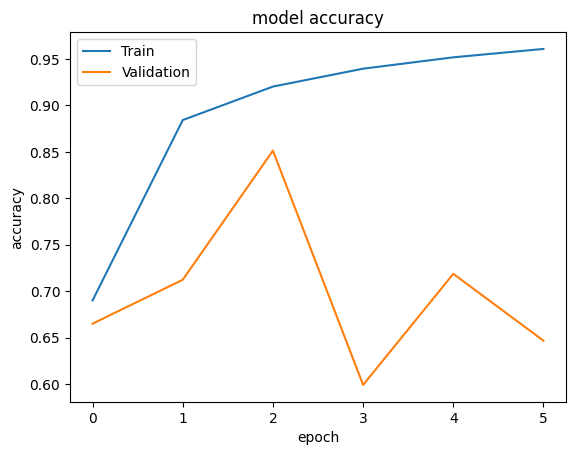

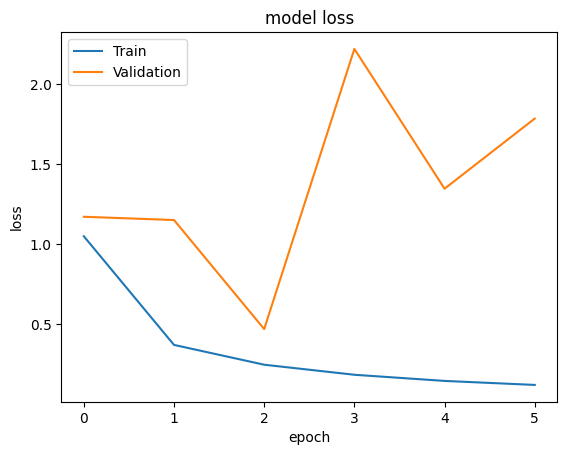

In [ ]:
#Plotting data
import matplotlib.pyplot as plt

plt.plot(Model.history['accuracy'])
plt.plot(Model.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

plt.plot(Model.history['loss'])
plt.plot(Model.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()